# Literature comparison with Ghia et al. using Re = 500

This notebook creates a quick fallback literature comparison if the `Re = 1000, 65 x 65` run is taking too long.

Ghia et al. do not tabulate `Re = 500`, so this compares the present `Re = 500` centerline profiles against the published Ghia benchmark profiles at `Re = 100`, `Re = 400`, and `Re = 1000`. It also plots the present `Re = 100`, `17 x 17` solver result when the field cache is available or regenerated.

The expected result is qualitative bracketing: the `Re = 500` profile should generally fall between the `Re = 400` and `Re = 1000` benchmark trends, while the `Re = 100` solver line and Ghia data provide a lower-Reynolds-number reference.

In [1]:
from pathlib import Path
import contextlib
import io
import json
import os
import shutil
import time

import matplotlib.pyplot as plt
import numpy as np

if Path.cwd().name != "start-code" and (Path.cwd() / "start-code").exists():
    os.chdir(Path.cwd() / "start-code")

plot_dir = Path("Phase III Ghia Literature Comparison Re500 Bracket")
plot_dir.mkdir(exist_ok=True)
cache_dir = plot_dir / "case_cache"
cache_dir.mkdir(exist_ok=True)

print(f"Working directory: {Path.cwd()}")
print(f"Plot output directory: {plot_dir.resolve()}")
print(f"Cache directory: {cache_dir.resolve()}")

Working directory: /Users/windy/mae4100-courseproject2/start-code
Plot output directory: /Users/windy/mae4100-courseproject2/start-code/Phase III Ghia Literature Comparison Re500 Bracket
Cache directory: /Users/windy/mae4100-courseproject2/start-code/Phase III Ghia Literature Comparison Re500 Bracket/case_cache


In [2]:
# Ghia, Ghia & Shin (1982), Table I and Table II.
# These are dimensionless centerline velocity values for the square lid-driven cavity.

ghia_y = np.array([
    1.0000, 0.9766, 0.9688, 0.9609, 0.9531, 0.8516, 0.7344, 0.6172, 0.5000,
    0.4531, 0.2813, 0.1719, 0.1016, 0.0703, 0.0625, 0.0547, 0.0000,
])

ghia_u_re100 = np.array([
    1.00000, 0.84123, 0.78871, 0.73722, 0.68717, 0.23151, 0.00332, -0.13641,
    -0.20581, -0.21090, -0.15662, -0.10150, -0.06434, -0.04775, -0.04192,
    -0.03717, 0.00000,
])

ghia_u_re400 = np.array([
    1.00000, 0.75837, 0.68439, 0.61756, 0.55892, 0.29093, 0.16256, 0.02135,
    -0.11477, -0.17119, -0.32726, -0.24299, -0.14612, -0.10338, -0.09266,
    -0.08186, 0.00000,
])

ghia_u_re1000 = np.array([
    1.00000, 0.65928, 0.57492, 0.51117, 0.46604, 0.33304, 0.18719, 0.05702,
    -0.06080, -0.10648, -0.27805, -0.38289, -0.29730, -0.22220, -0.20196,
    -0.18109, 0.00000,
])

ghia_x = np.array([
    1.0000, 0.9688, 0.9609, 0.9531, 0.9453, 0.9063, 0.8594, 0.8047, 0.5000,
    0.2344, 0.2266, 0.1563, 0.0938, 0.0781, 0.0703, 0.0625, 0.0000,
])

ghia_v_re100 = np.array([
    0.00000, -0.05906, -0.07391, -0.08864, -0.10313, -0.16914, -0.22445,
    -0.24533, 0.05454, 0.17527, 0.17507, 0.16077, 0.12317, 0.10890,
    0.10091, 0.09233, 0.00000,
])

ghia_v_re400 = np.array([
    0.00000, -0.12146, -0.15663, -0.19254, -0.22847, -0.23827, -0.44993,
    -0.38598, 0.05188, 0.30174, 0.30203, 0.28124, 0.22965, 0.20920,
    0.19713, 0.18360, 0.00000,
])

ghia_v_re1000 = np.array([
    0.00000, -0.21388, -0.27669, -0.33714, -0.39188, -0.51550, -0.42665,
    -0.31966, 0.02526, 0.32235, 0.33075, 0.37095, 0.32627, 0.30353,
    0.29012, 0.27485, 0.00000,
])

In [3]:
RE500_CASE = {"Re": 500.0, "nodes": 33, "h_label": 4, "cfl": 0.20}
RE100_CASE = {"Re": 100.0, "nodes": 17, "h_label": 8, "cfl": 0.35}
RUN_RE500_IF_CACHE_MISSING = True
RUN_RE100_IF_CACHE_MISSING = True


def case_label(case):
    return f"Re{int(case['Re']):04d}_{case['nodes']}x{case['nodes']}"


def format_solver_float(value):
    return f"{value:<16g}"


def apply_replacements(source, replacements, solver_path):
    for old, new in replacements.items():
        if old not in source:
            raise RuntimeError(f"Could not find expected setting in {solver_path}: {old}")
        source = source.replace(old, new, 1)
    return source


def patched_solver_source(case):
    solver_path = Path("main_solver.py")
    source = solver_path.read_text()
    nodes = case["nodes"]
    replacements = {
        "imax = 9               # Number of points in the x-direction (use odd numbers only)":
            f"imax = {nodes:<15}# Number of points in the x-direction (use odd numbers only)",
        "jmax = 9               # Number of points in the y-direction (use odd numbers only)":
            f"jmax = {nodes:<15}# Number of points in the y-direction (use odd numbers only)",
        "cfl = 0.5              # CFL number used to determine time step":
            f"cfl = {format_solver_float(case['cfl'])}# CFL number used to determine time step",
        "Re = 10.0              # Reynolds number = rho*Uinf*L/rmu":
            f"Re = {format_solver_float(case['Re'])}# Reynolds number = rho*Uinf*L/rmu",
        "iterout = 5000         # Number of time steps between solution output":
            "iterout = 100000000    # Number of time steps between solution output",
        "vectorize = False":
            "vectorize = True",
    }
    return solver_path, apply_replacements(source, replacements, solver_path)


def cache_paths(case):
    label = case_label(case)
    return cache_dir / f"{label}.npz", cache_dir / f"{label}.json"


def load_cached_case(case):
    label = case_label(case)
    candidate_cache_dirs = [
        cache_dir,
        Path("Phase III Reynolds Re500 Re1000 Coupled Standard") / "case_cache",
        Path("Phase III Reynolds Comparison Mesh Refinement") / "case_cache",
        Path("Phase III Reynolds Comparison Mesh Refinement Accelerated") / "case_cache",
    ]

    for candidate_cache_dir in candidate_cache_dirs:
        npz_path = candidate_cache_dir / f"{label}.npz"
        json_path = candidate_cache_dir / f"{label}.json"
        if npz_path.exists() and json_path.exists():
            arrays = np.load(npz_path)
            metadata = json.loads(json_path.read_text())
            metadata["u"] = arrays["u"]
            metadata["convVector"] = arrays["convVector"] if "convVector" in arrays.files else np.array([])
            metadata["res"] = arrays["res"] if "res" in arrays.files else np.array([])
            print(f"Loaded cached case from {npz_path}")
            return metadata

    return None


def save_cached_case(case, result):
    npz_path, json_path = cache_paths(case)
    np.savez_compressed(
        npz_path,
        u=result["u"],
        convVector=result.get("convVector", np.array([])),
        res=result.get("res", np.array([])),
    )
    metadata = {k: v for k, v in result.items() if k not in {"u", "convVector", "res", "captured_output"}}
    metadata["captured_output_tail"] = result.get("captured_output", "").splitlines()[-12:]
    json_path.write_text(json.dumps(metadata, indent=2))


def archive_solver_plots(label):
    case_plot_dir = plot_dir / label
    case_plot_dir.mkdir(exist_ok=True)
    for filename in ["ucontour.png", "vcontour.png", "pcontour.png", "residualcomponent.png", "residual.png"]:
        src = Path(filename)
        if src.exists():
            dst = case_plot_dir / filename
            if dst.exists():
                dst.unlink()
            shutil.move(str(src), str(dst))


def run_or_load_case(case, run_if_missing):
    cached = load_cached_case(case)
    if cached is not None:
        return cached

    if not run_if_missing:
        raise FileNotFoundError(
            f"No array cache was found for {case_label(case)}. "
            "Set the matching RUN_*_IF_CACHE_MISSING flag to True to rerun the case."
        )

    label = case_label(case)
    solver_path, source = patched_solver_source(case)
    namespace = {"__file__": str(solver_path.resolve()), "__name__": "__main__"}

    print(f"Running fallback coupled SGS case {label}.")
    start_time = time.perf_counter()
    with contextlib.redirect_stdout(io.StringIO()) as captured_output:
        exec(compile(source, str(solver_path), "exec"), namespace)
    elapsed_time = time.perf_counter() - start_time
    archive_solver_plots(label)
    plt.close("all")

    u = namespace["u"].copy()
    imax, jmax, _ = u.shape
    result = {
        "label": label,
        "solver_method": namespace["solver_method"],
        "Re": case["Re"],
        "nodes": case["nodes"],
        "h_label": case["h_label"],
        "cfl": case["cfl"],
        "dx": (namespace["xmax"] - namespace["xmin"]) / (imax - 1),
        "dy": (namespace["ymax"] - namespace["ymin"]) / (jmax - 1),
        "viscosity": float(namespace["rmu"]),
        "iterations": int(namespace["n"]),
        "converged": bool(namespace["isConverged"]),
        "final_conv": float(namespace["conv"]),
        "elapsed_time_sec": float(elapsed_time),
        "xmin": float(namespace["xmin"]),
        "xmax": float(namespace["xmax"]),
        "ymin": float(namespace["ymin"]),
        "ymax": float(namespace["ymax"]),
        "u": u,
        "res": np.array(namespace["res"], copy=True),
        "convVector": np.array(namespace["convVector"], copy=True),
        "captured_output": captured_output.getvalue(),
    }
    save_cached_case(case, result)
    print(f"Saved {label} cache to {cache_dir.resolve()}")
    return result


result_re500 = run_or_load_case(RE500_CASE, RUN_RE500_IF_CACHE_MISSING)
result_re100 = run_or_load_case(RE100_CASE, RUN_RE100_IF_CACHE_MISSING)

for result in [result_re100, result_re500]:
    print({k: result[k] for k in ["label", "nodes", "iterations", "converged", "final_conv", "elapsed_time_sec"]})

Loaded cached case from Phase III Reynolds Re500 Re1000 Coupled Standard/case_cache/Re0500_33x33.npz
Loaded cached case from Phase III Reynolds Comparison Mesh Refinement/case_cache/Re0100_17x17.npz
{'label': 'Re0100_17x17', 'nodes': 17, 'iterations': 2545, 'converged': True, 'final_conv': 9.96275594257118e-11, 'elapsed_time_sec': 572.7119446659926}
{'label': 'Re0500_33x33', 'nodes': 33, 'iterations': 41516, 'converged': True, 'final_conv': 9.683562580589106e-11, 'elapsed_time_sec': 372.5748204580159}


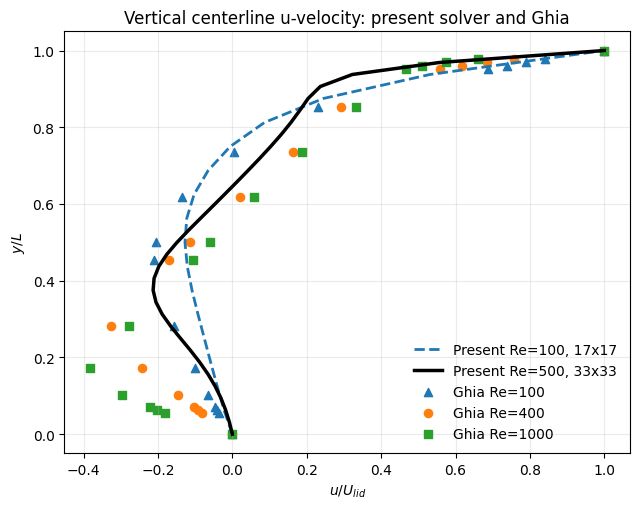

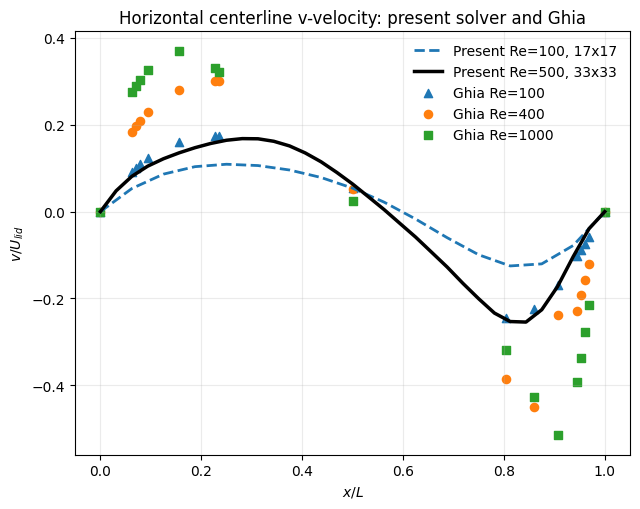

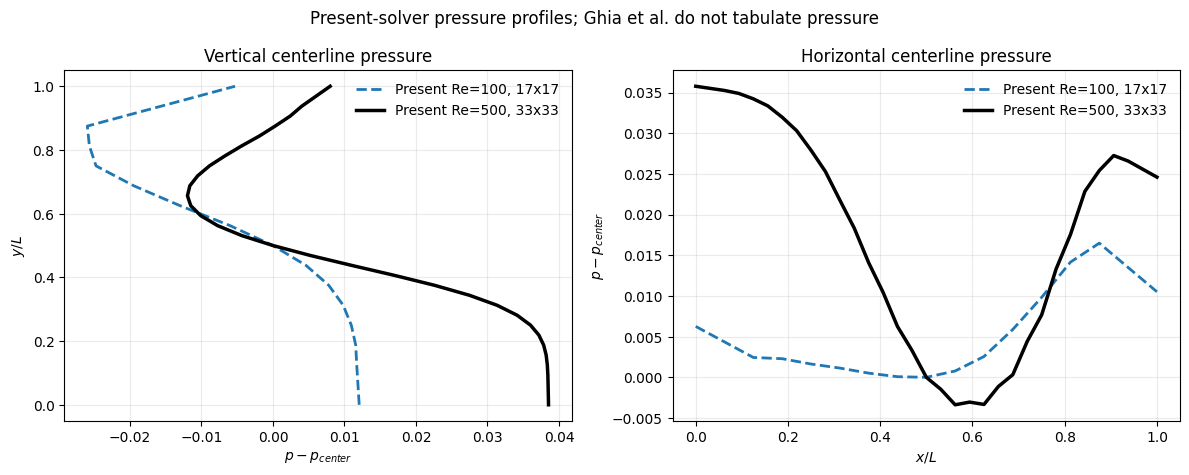

Saved: Phase III Ghia Literature Comparison Re500 Bracket/ghia_bracket_vertical_centerline_u_Re500.png
Saved: Phase III Ghia Literature Comparison Re500 Bracket/ghia_bracket_horizontal_centerline_v_Re500.png
Saved: Phase III Ghia Literature Comparison Re500 Bracket/present_pressure_centerlines_Re100_Re500.png


In [4]:
def normalized_coordinates(result):
    nodes = result["u"].shape[0]
    x = np.linspace(result["xmin"], result["xmax"], nodes)
    y = np.linspace(result["ymin"], result["ymax"], nodes)
    length = result["xmax"] - result["xmin"]
    return x / length, y / length


def centerline_profiles(result):
    u_solution = result["u"]
    x_norm, y_norm = normalized_coordinates(result)
    i_mid = (u_solution.shape[0] - 1) // 2
    j_mid = (u_solution.shape[1] - 1) // 2
    u_lid = 1.0
    return {
        "x_norm": x_norm,
        "y_norm": y_norm,
        "u_centerline": u_solution[i_mid, :, 1] / u_lid,
        "v_centerline": u_solution[:, j_mid, 2] / u_lid,
    }


present_re100 = centerline_profiles(result_re100)
present_re500 = centerline_profiles(result_re500)

plt.figure(figsize=(6.5, 5.2))
plt.plot(
    present_re100["u_centerline"], present_re100["y_norm"],
    color="tab:blue", linewidth=2.0, linestyle="--", label="Present Re=100, 17x17"
)
plt.plot(
    present_re500["u_centerline"], present_re500["y_norm"],
    color="black", linewidth=2.5, label="Present Re=500, 33x33"
)
plt.scatter(ghia_u_re100, ghia_y, marker="^", s=35, label="Ghia Re=100")
plt.scatter(ghia_u_re400, ghia_y, marker="o", s=35, label="Ghia Re=400")
plt.scatter(ghia_u_re1000, ghia_y, marker="s", s=35, label="Ghia Re=1000")
plt.xlabel(r"$u/U_{lid}$")
plt.ylabel(r"$y/L$")
plt.title("Vertical centerline u-velocity: present solver and Ghia")
plt.grid(True, alpha=0.25)
plt.legend(frameon=False)
plt.tight_layout()
vertical_plot = plot_dir / "ghia_bracket_vertical_centerline_u_Re500.png"
plt.savefig(vertical_plot, dpi=300)
plt.show()

plt.figure(figsize=(6.5, 5.2))
plt.plot(
    present_re100["x_norm"], present_re100["v_centerline"],
    color="tab:blue", linewidth=2.0, linestyle="--", label="Present Re=100, 17x17"
)
plt.plot(
    present_re500["x_norm"], present_re500["v_centerline"],
    color="black", linewidth=2.5, label="Present Re=500, 33x33"
)
plt.scatter(ghia_x, ghia_v_re100, marker="^", s=35, label="Ghia Re=100")
plt.scatter(ghia_x, ghia_v_re400, marker="o", s=35, label="Ghia Re=400")
plt.scatter(ghia_x, ghia_v_re1000, marker="s", s=35, label="Ghia Re=1000")
plt.xlabel(r"$x/L$")
plt.ylabel(r"$v/U_{lid}$")
plt.title("Horizontal centerline v-velocity: present solver and Ghia")
plt.grid(True, alpha=0.25)
plt.legend(frameon=False)
plt.tight_layout()
horizontal_plot = plot_dir / "ghia_bracket_horizontal_centerline_v_Re500.png"
plt.savefig(horizontal_plot, dpi=300)
plt.show()

print(f"Saved: {vertical_plot}")
print(f"Saved: {horizontal_plot}")